# Notebook para entrenar modelos

# Entrenamiento del CVAE

Usando mnist como dataset
Epoch 1/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 6.9276 - loss: 45.7031 - reconstruction_loss: 41.5521 - val_kl_loss: 10.2461 - val_loss: 35.9341 - val_reconstruction_loss: 29.8485 - learning_rate: 0.0010
Epoch 2/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 10.6868 - loss: 34.3329 - reconstruction_loss: 27.9203 - val_kl_loss: 10.5962 - val_loss: 32.2162 - val_reconstruction_loss: 25.8303 - learning_rate: 0.0010
Epoch 3/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 11.2481 - loss: 31.8765 - reconstruction_loss: 25.1270 - val_kl_loss: 11.3525 - val_loss: 30.4760 - val_reconstruction_loss: 23.6409 - learning_rate: 0.0010
Epoch 4/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 11.7859 - loss: 30.2205 - reconstruction_loss: 23.1478 - val_kl_loss: 11.7854 - val_loss: 29.0473 - val_reconstruction_loss: 21.9508 - learning_rate: 0.0010
Epoch 5/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - kl_loss: 12.2044 - loss: 28.6429 - recons

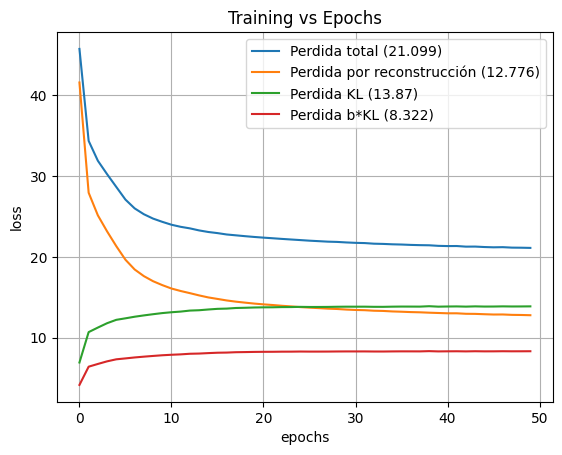

In [6]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from project.loader import Loader
from project.models_definitions import Encoder, Decoder, CVAE
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.callbacks import EarlyStopping

## parametros
dataset="mnist"
data = Loader.data(dataset=dataset)

x_train = data["x_train"]
y_train = data["y_train"]

x_test = data["x_test"]
y_test =data["y_test"]

x_val = data["x_val"]
y_vearly_stoppingal = data["y_val"]

original_dim = 28*28
beta = 0.6

train_dataset = tf.data.Dataset.from_tensor_slices(((x_train, y_train), x_train))
train_dataset = train_dataset.batch(128)

val_dataset = tf.data.Dataset.from_tensor_slices(((x_val, y_val), x_val))
val_dataset = val_dataset.batch(128)

#intermediate_dim = [128,128,256,256,512,512,784]
#latent_dim =      [2,64,64,128,128,256,784]
intermediate_dim = [512]
latent_dim =       [256]
beta =             [0.6] # 0.4 iguala las perdidas



for i,l,b in zip(intermediate_dim,latent_dim,beta):

    en = Encoder(
        intermediate_dim=i,
        latent_dim=l,
    )
    de = Decoder(
        intermediate_dim=i,
        latent_dim=l,
    )
    b_str = str(b).replace('.', '_')
    cvae_model = CVAE(
        encoder=en,
        decoder=de,
        original_dim=original_dim,
        beta=b,
        name=f"cvae_int_{i}_lat_{l}_beta_{b}",
    )


    optimizer = tf.keras.optimizers.Adam()
    cvae_model.compile(optimizer=optimizer)


    cvae_model.total_loss_tracker.reset_state()
    cvae_model.reconstruction_loss_tracker.reset_state()
    cvae_model.kl_loss_tracker.reset_state()


    early_stopping_cvae = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=30,
        min_delta=1e-4,
        start_from_epoch=20,
        restore_best_weights=True
    )

    cp_callback_cvae = tf.keras.callbacks.ModelCheckpoint(
        filepath=PATHS["CVAE_WEIGHTS"],
        save_weights_only=True,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    )

    reduce_lr_cvae = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=10,
        min_lr=1e-6,
        verbose=1
    )

    history = cvae_model.fit(
        train_dataset,
        epochs=50,
        batch_size=128,
        validation_data=val_dataset,
        callbacks=[early_stopping_cvae,
                   reduce_lr_cvae],
        verbose=1
    )
    b_str = str(b).replace('.', '_')
   
    en.save(f"en_int_{i}_lat_{l}_beta_{b_str}_{dataset}.keras")
    de.save(f"de_int_{i}_lat_{l}_beta_{b_str}_{dataset}.keras")


    import numpy as np

    kl_loss = np.array(history.history["kl_loss"])
    beta_kl_loss = kl_loss * b

    loss_val = round(history.history["loss"][-1], 3)
    recon_val = round(history.history["reconstruction_loss"][-1], 3)
    kl_val = round(kl_loss[-1], 3)
    beta_kl_val = round(beta_kl_loss[-1], 3)
    
    plt.plot(history.history["loss"], label=f"Perdida total ({loss_val})")
    plt.plot(history.history["reconstruction_loss"], label=f"Perdida por reconstrucción ({recon_val})")
    plt.plot(kl_loss, label=f"Perdida KL ({kl_val})")
    plt.plot(beta_kl_loss, label=f"Perdida b*KL ({beta_kl_val})")
    
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.grid()
    plt.title("Training vs Epochs")
    plt.legend()
    plt.savefig(f"loss_vs_epochs_model_int_{i}_lat_{l}_beta_{b_str}_{dataset}")
    plt.show()
    loss_val = round(history.history["loss"][-1], 3)
    val_loss_val = round(history.history["val_loss"][-1], 3)
    
    # plt.plot(history.history["loss"], label=f"total_loss ({loss_val})")
    # plt.plot(history.history["val_loss"], label=f"val_loss ({val_loss_val})")
    # plt.xlabel("epochs")
    # plt.ylabel("loss")
    # plt.grid()
    # plt.title("Training vs Validation Loss")
    # plt.legend()
    #plt.savefig(f"training_loss_vs_val_loss_model_int_{i}_lat_{l}_beta_{b_str}_{dataset}")
    # plt.show()


# Predictor

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from project.loader import Loader
from project.models_definitions import Predictor
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.callbacks import EarlyStopping

#Constantes
BATCH_SIZE = 128
DATASET = "mnist" # mnist o fashion
EPOCHS= 3

## parametros
data = Loader.data(dataset=DATASET)

x_train = data["x_train"]
y_train = data["y_train"]

x_val = data["x_val"]
y_val = data["y_val"]


train_dataset = tf.data.Dataset.from_tensor_slices(((x_train, y_train), x_train))
train_dataset = train_dataset.batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices(((x_val, y_val), x_val))
val_dataset = val_dataset.batch(BATCH_SIZE)

predictor = Predictor()

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

predictor.compile(optimizer, loss="categorical_crossentropy")


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = predictor.fit(
    x=x_train,
    y=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=1)

loss = round(history.history["loss"][-1], 3)
loss_val = round(history.history["val_loss"][-1], 3)

#predictor.save("early_stop_fashion.keras") #descomentar para guardar
plt.plot(history.history["loss"], label=f"Loss {loss}" )
plt.plot(history.history["val_loss"], label=f"Validation_loss {loss_val}" )
plt.title("Training vs Validation Loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.grid()
plt.legend()
#plt.savefig(f"loss_vs_epochs_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}") #descomentar para guardar
plt.show()

# Test de modelo entrenado. 

## CVAE

In [ ]:

print("\n--- LATENT ANALYSIS ---")

z_mean, z_log_var, _ = cvae_encoder.predict([x_val, y_val], verbose=0)

kl = -0.5 * np.sum(
    1 + z_log_var - np.square(z_mean) - np.exp(z_log_var),
    axis=1
)

x_recon = decoder.predict([z_mean, y_val], verbose=0)

recon = np.sum((x_val - x_recon) ** 2, axis=1)

print("Recon mean:", np.mean(recon))
print("KL mean:", np.mean(kl))

# Predictor

In [5]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from project.loader import Loader
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.callbacks import EarlyStopping

dataset = "fashion"

predictor = Loader.predictor(dataset=dataset)
data  = Loader.data(dataset=dataset)

x_train = data["x_train"]
y_train = data["y_train"]

x_test = data["x_test"]
y_test =data["y_test"]

x_val = data["x_val"]
y_val = data["y_val"]

original_dim = 28*28
beta = 1.0




Usando fashion como dataset


In [6]:
import numpy as np

def evaluate_predictor(predictor, x_train, y_train, x_val, y_val, x_test, y_test):

    # Predictions
    y_pred_train = np.argmax(predictor.predict(x_train, verbose=0), axis=1)
    y_pred_val   = np.argmax(predictor.predict(x_val,   verbose=0), axis=1)
    y_pred_test  = np.argmax(predictor.predict(x_test,  verbose=0), axis=1)

    # Ground truth
    y_train_true = np.argmax(y_train, axis=1)
    y_val_true   = np.argmax(y_val,   axis=1)
    y_test_true  = np.argmax(y_test,  axis=1)

    # Accuracy
    acc_train = np.mean(y_pred_train == y_train_true)
    acc_val   = np.mean(y_pred_val   == y_val_true)
    acc_test  = np.mean(y_pred_test  == y_test_true)

    print(f"Train Accuracy: {acc_train:.4f}")
    print(f"Val   Accuracy: {acc_val:.4f}")
    print(f"Test  Accuracy: {acc_test:.4f}")

    return acc_train, acc_val, acc_test


evaluate_predictor(
    predictor,
    x_train, y_train,
    x_val, y_val,
    x_test, y_test
)


Train Accuracy: 0.9151
Val   Accuracy: 0.9002
Test  Accuracy: 0.8965


(np.float64(0.9151454545454546), np.float64(0.9002), np.float64(0.8965))

## Matriz de confución 

In [4]:
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 29.4 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [seaborn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Usando mnist como dataset


2026-04-11 16:09:37.116054: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


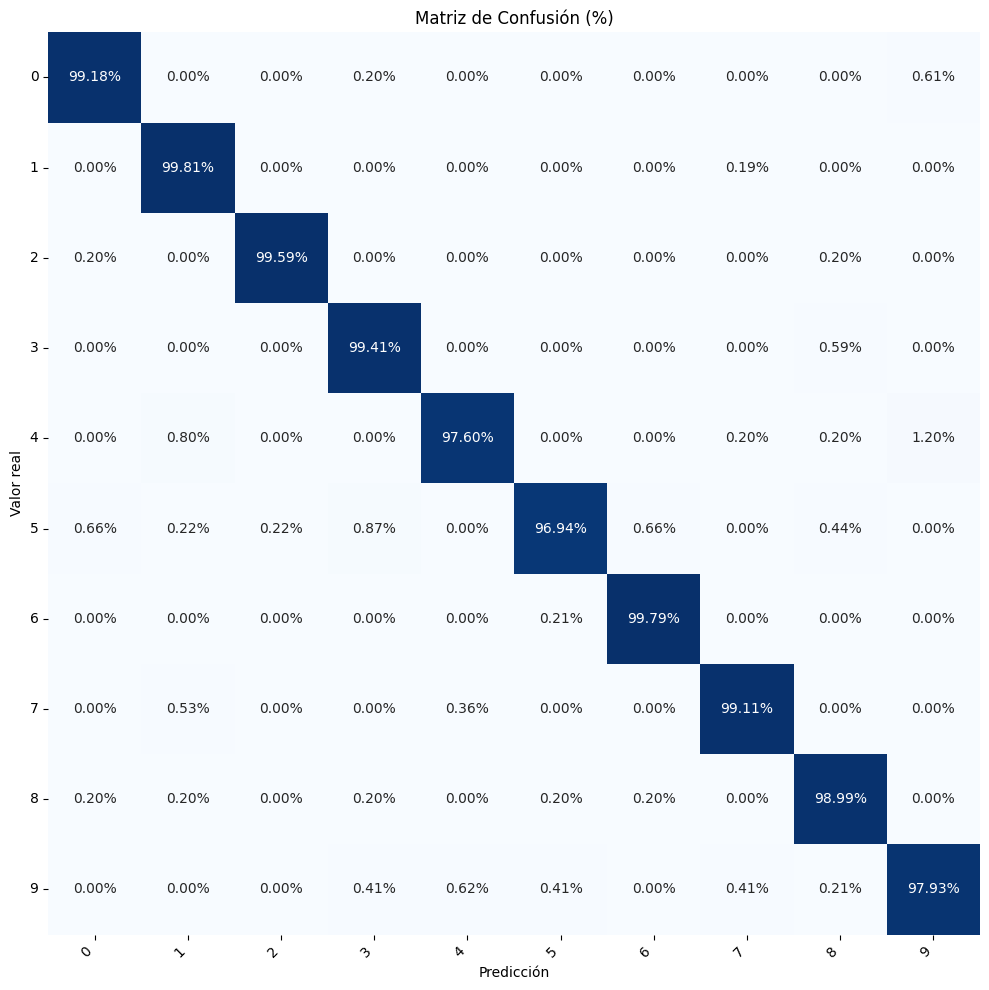

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       489
           1       0.98      1.00      0.99       530
           2       1.00      1.00      1.00       493
           3       0.98      0.99      0.99       509
           4       0.99      0.98      0.98       499
           5       0.99      0.97      0.98       458
           6       0.99      1.00      0.99       482
           7       0.99      0.99      0.99       563
           8       0.98      0.99      0.99       494
           9       0.98      0.98      0.98       483

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from project.visualizations import visualizations
from project.loader import Loader
import tensorflow as tf

dataset = "mnist"

predictor = Loader.predictor(dataset=dataset)
data = Loader.data(dataset)
x_train = data["x_train"]
y_train = data["y_train"]

x_test = data["x_test"]
y_test =data["y_test"]

x_val = data["x_val"]
y_val = data["y_val"]
labels = data["labels"]


train_dataset = tf.data.Dataset.from_tensor_slices(((x_train, y_train), x_train))
train_dataset = train_dataset.batch(128)

val_dataset = tf.data.Dataset.from_tensor_slices(((x_val, y_val), x_val))
val_dataset = val_dataset.batch(128)

visualizations.confusion_matrix_plot(predictor=predictor,dataset=val_dataset,label_names=labels)



## Predictor con mayor numero de capas

In [15]:
import tensorflow as tf
from keras.layers import Dense, Conv2D, BatchNormalization, Dropout, Flatten
from project.custom_layers.reshapeLayer import ReshapeLayer


class Predictor2(tf.keras.Model):
    def __init__(
        self,
        image_size=28,
        n_cond=10,
        dropout_rate=0.5,
        name="predictor",
        **kwargs,
    ):
        super().__init__(name=name, **kwargs)

        self.image_size = image_size
        self.original_dim = image_size * image_size
        self.original_dim_C = (image_size, image_size, 1)

        # =========================
        # Layers
        # =========================
        self.reshape = ReshapeLayer(self.original_dim_C)

        # 🔹 Bloque 1
        self.conv1 = Conv2D(128, 3, strides=2, padding="same", activation="relu")
        self.bn1 = BatchNormalization()

        # 🔹 Bloque 2
        self.conv2 = Conv2D(256, 3, strides=2, padding="same", activation="relu")
        self.bn2 = BatchNormalization()

        # 🔹 Bloque 3 (NUEVO → más compresión)
        self.conv3 = Conv2D(512, 3, strides=2, padding="same", activation="relu")
        self.bn3 = BatchNormalization()

        self.flatten = Flatten()

        # 🔹 Capa intermedia (mejora representación)
        self.dense = Dense(512, activation="relu")

        self.dropout = Dropout(dropout_rate)

        # 🔹 Capa intermedia (mejora representación)
        self.dense = Dense(512, activation="relu")

        self.dropout = Dropout(dropout_rate)

        # 🔹 Clasificador final
        self.classifier = Dense(n_cond, activation="softmax")

    def call(self, inputs, training=False):
        x = self.reshape(inputs)

        x = self.conv1(x)
        x = self.bn1(x, training=training)

        x = self.conv2(x)
        x = self.bn2(x, training=training)

        x = self.conv3(x)
        x = self.bn3(x, training=training)

        x = self.flatten(x)

        x = self.dense(x)
        x = self.dropout(x, training=training)

        return self.classifier(x)

Usando fashion como dataset
Epoch 1/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 58s 132ms/step - loss: 0.5341 - val_loss: 0.9417
Epoch 2/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 61s 142ms/step - loss: 0.3442 - val_loss: 0.2756
Epoch 3/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 65s 152ms/step - loss: 0.2858 - val_loss: 0.2975
Epoch 4/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 67s 155ms/step - loss: 0.2566 - val_loss: 0.2752
Epoch 5/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 69s 161ms/step - loss: 0.2254 - val_loss: 0.2852
Epoch 6/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 71s 164ms/step - loss: 0.1964 - val_loss: 0.2687
Epoch 7/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 71s 166ms/step - loss: 0.1729 - val_loss: 0.2697
Epoch 8/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 69s 160ms/step - loss: 0.1567 - val_loss: 0.2666
Epoch 9/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 70s 162ms/step - loss: 0.1313 - val_loss: 0.2988
Epoch 10/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 66s 153ms/step - loss: 0.1152 - val_loss: 0.3395
Epoch 11/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 67s 156ms/step - loss: 0.1051

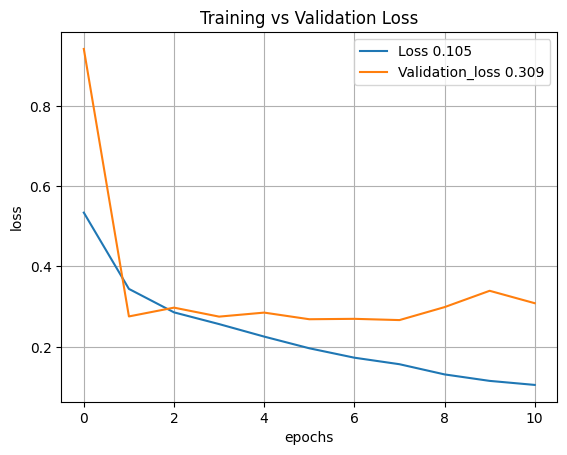

In [17]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from project.loader import Loader
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.callbacks import EarlyStopping

#Constantes
BATCH_SIZE = 128
DATASET = "fashion" # mnist o fashion
EPOCHS= 100

## parametros
data = Loader.data(dataset=DATASET)

x_train = data["x_train"]
y_train = data["y_train"]

x_val = data["x_val"]
y_val = data["y_val"]


train_dataset = tf.data.Dataset.from_tensor_slices(((x_train, y_train), x_train))
train_dataset = train_dataset.batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices(((x_val, y_val), x_val))
val_dataset = val_dataset.batch(BATCH_SIZE)

predictor = Predictor2()

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

predictor.compile(optimizer, loss="categorical_crossentropy")


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = predictor.fit(
    x=x_train,
    y=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=1)

loss = round(history.history["loss"][-1], 3)
loss_val = round(history.history["val_loss"][-1], 3)

#predictor.save("early_stop_fashion.keras") #descomentar para guardar
plt.plot(history.history["loss"], label=f"Loss {loss}" )
plt.plot(history.history["val_loss"], label=f"Validation_loss {loss_val}" )
plt.title("Training vs Validation Loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.grid()
plt.legend()
#plt.savefig(f"loss_vs_epochs_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}") #descomentar para guardar
plt.show()

Usando fashion como dataset


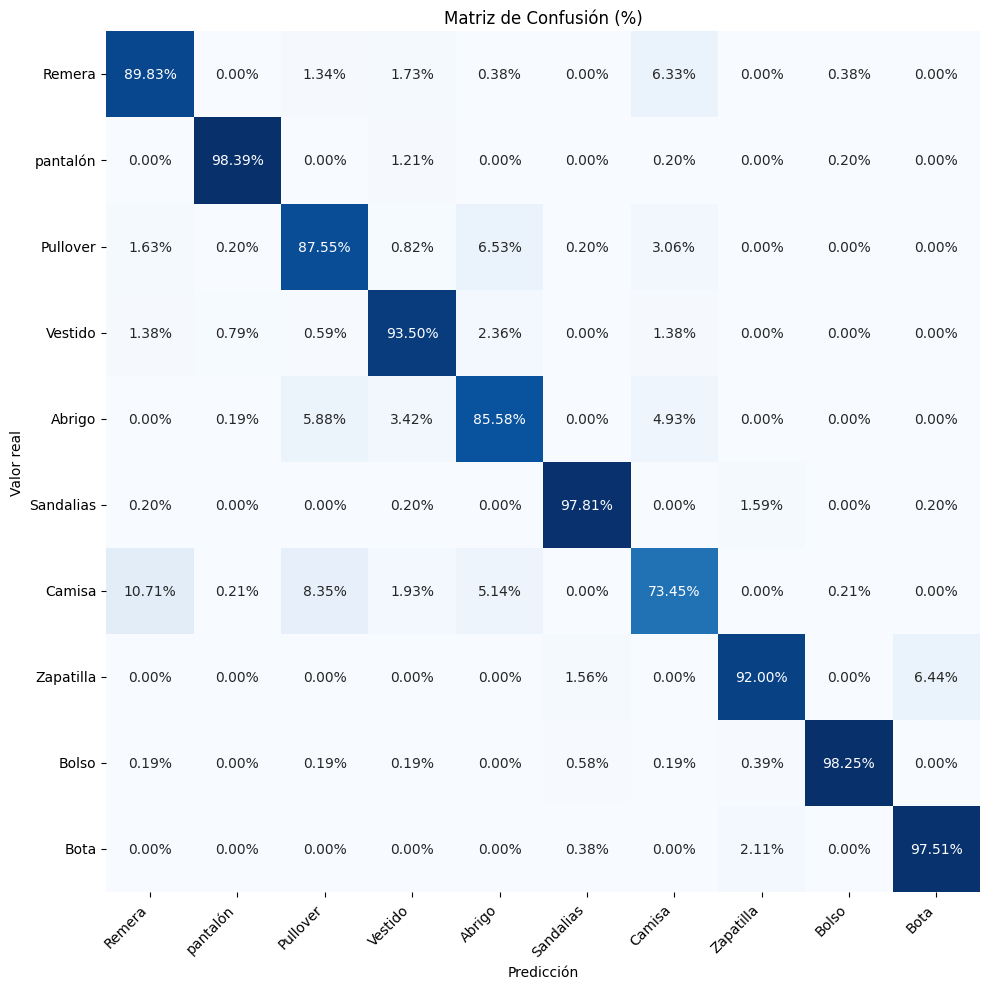

              precision    recall  f1-score   support

      Remera       0.87      0.90      0.89       521
    pantalón       0.99      0.98      0.98       497
    Pullover       0.84      0.88      0.86       490
     Vestido       0.91      0.94      0.92       508
      Abrigo       0.87      0.86      0.86       527
   Sandalias       0.97      0.98      0.98       503
      Camisa       0.81      0.73      0.77       467
   Zapatilla       0.95      0.92      0.94       450
       Bolso       0.99      0.98      0.99       515
        Bota       0.94      0.98      0.96       522

    accuracy                           0.92      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.92      0.91      5000



In [18]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from project.visualizations import visualizations
from project.loader import Loader
import tensorflow as tf

dataset = "fashion"

data = Loader.data(dataset)
x_train = data["x_train"]
y_train = data["y_train"]

x_test = data["x_test"]
y_test =data["y_test"]

x_val = data["x_val"]
y_val = data["y_val"]
labels = data["labels"]


train_dataset = tf.data.Dataset.from_tensor_slices(((x_train, y_train), x_train))
train_dataset = train_dataset.batch(128)

val_dataset = tf.data.Dataset.from_tensor_slices(((x_val, y_val), x_val))
val_dataset = val_dataset.batch(128)

visualizations.confusion_matrix_plot(predictor=predictor,dataset=val_dataset,label_names=labels)



In [19]:
import numpy as np

preds = predictor(x_val, training=False)
y_pred = np.argmax(preds.numpy(), axis=1)

y_true = y_val
if len(y_true.shape) > 1:
    y_true = np.argmax(y_true, axis=1)

accuracy = np.mean(y_pred == y_true)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9152


# Codigo de Veiga

In [2]:
# =============================================================================
# DATA
# =============================================================================

import numpy as np
from tensorflow.keras.datasets import mnist, fashion_mnist
from tensorflow.keras.utils import to_categorical
import numpy as np



def load_mnist(image_size=28):
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    #(x_train, y_train), (x_test, y_test) =fashion_mnist.load_data()

    x_train = x_train.astype("float32") / 255.0
    x_test  = x_test.astype("float32") / 255.0

    x_train = x_train.reshape(-1, image_size * image_size)
    x_test  = x_test.reshape(-1, image_size * image_size)

    # One-hot
    y_train = to_categorical(y_train, 10)
    y_test  = to_categorical(y_test, 10)

    # Split train / val
    split = int(0.91667 * len(x_train))
    x_val = x_train[split:]
    y_val = y_train[split:]

    x_train = x_train[:split]
    y_train = y_train[:split]

    return x_train, y_train, x_val, y_val, x_test, y_test

# =============================================================================
# LINES GENERATION
# =============================================================================

def generate_line_image(image_size=28, n_vertical=2, n_horizontal=2, thickness=1):
    img = np.zeros((image_size, image_size), dtype=np.float32)

    cols = np.random.choice(image_size, n_vertical, replace=False)
    for c in cols:
        img[:, max(0, c-thickness):min(image_size, c+thickness+1)] = 1.0

    rows = np.random.choice(image_size, n_horizontal, replace=False)
    for r in rows:
        img[max(0, r-thickness):min(image_size, r+thickness+1), :] = 1.0

    return img


def generate_lines_dataset(n_samples, image_size=28, n_vertical=2, n_horizontal=2, thickness=1):
    data = np.zeros((n_samples, image_size * image_size), dtype=np.float32)

    for i in range(n_samples):
        img = generate_line_image(image_size, n_vertical, n_horizontal, thickness)
        data[i] = img.reshape(-1)

    return data


def build_dataset(CONFIG):
    image_size = CONFIG["IMAGE_SIZE"]
    noise      = CONFIG["NOISE"]
    lines_mode = CONFIG["LINES"]

    # ---------------- MNIST ----------------
    x_train, y_train, x_val, y_val, x_test, y_test = load_mnist(image_size)

    # ---------------- LINES PARAMS ----------------
    if lines_mode == "COARSE":
        thickness, n_vertical, n_horizontal = 1, 2, 2
    elif lines_mode == "THIN":
        thickness, n_vertical, n_horizontal = 0, 7, 7
    else:
        raise ValueError(f"Unknown LINES mode: {lines_mode}")

    # ---------------- LINES DATA ----------------
    n_train = x_train.shape[0] #// 10
    n_val   = x_val.shape[0]   #// 10
    n_test  = x_test.shape[0]  #// 10

    x_train_lines = generate_lines_dataset(n_train, image_size, n_vertical, n_horizontal, thickness)
    x_val_lines   = generate_lines_dataset(n_val,   image_size, n_vertical, n_horizontal, thickness)
    x_test_lines  = generate_lines_dataset(n_test,  image_size, n_vertical, n_horizontal, thickness)

    # ---------------- LABELS (11 classes) ----------------
    def expand_labels(y):
        y_exp = np.zeros((y.shape[0], 11), dtype=np.float32)
        y_exp[:, :10] = y
        return y_exp

    y_train_exp = expand_labels(y_train)
    y_val_exp   = expand_labels(y_val)
    y_test_exp  = expand_labels(y_test)

    y_lines_train = np.zeros((x_train_lines.shape[0], 11), dtype=np.float32)
    y_lines_train[:, 10] = 1.0

    y_lines_val = np.zeros((x_val_lines.shape[0], 11), dtype=np.float32)
    y_lines_val[:, 10] = 1.0

    y_lines_test = np.zeros((x_test_lines.shape[0], 11), dtype=np.float32)
    y_lines_test[:, 10] = 1.0

    # ---------------- COMBINE ----------------
    x_train_total = np.concatenate([x_train, x_train_lines], axis=0)
    y_train_total = np.concatenate([y_train_exp, y_lines_train], axis=0)

    x_val_total = np.concatenate([x_val, x_val_lines], axis=0)
    y_val_total = np.concatenate([y_val_exp, y_lines_val], axis=0)

    x_test_total = np.concatenate([x_test, x_test_lines], axis=0)
    y_test_total = np.concatenate([y_test_exp, y_lines_test], axis=0)

    # ---------------- SHUFFLE ----------------
    def shuffle(x, y):
        perm = np.random.permutation(x.shape[0])
        return x[perm], y[perm]

    x_train_total, y_train_total = shuffle(x_train_total, y_train_total)
    x_val_total, y_val_total     = shuffle(x_val_total, y_val_total)
    x_test_total, y_test_total   = shuffle(x_test_total, y_test_total)


    # ---------------- OVERLAPPING ----------------

    if noise == "LINES":
        # Training --------------------------------
        x_train_total = x_train_total
        y_train_total = y_train_total
        x_val_total   = x_val_total
        y_val_total   = y_val_total
        # Testing ---------------------------------
        x_test        = x_test
        y_test        = y_test        
        x_test_1      = x_test_lines
        y_test_1      = y_lines_test
    elif noise == "DIGITS_T2":
        # Training --------------------------------
        x_train_total = x_train
        y_train_total = y_train
        x_val_total   = x_val
        y_val_total   = y_val
        # Testing ---------------------------------
        x_test        = x_test
        y_test        = y_test     
        perm = np.random.permutation(x_test.shape[0])
        x_test_1      = x_test[perm]
        y_test_1      = y_test[perm]
    elif noise == "DIGITS_T1":
        # Training --------------------------------
        x_train_total = x_train
        y_train_total = y_train
        x_val_total   = x_val
        y_val_total   = y_val
        # Testing ---------------------------------
        x_test        = x_test
        y_test        = y_test     
        x_test_1      = x_test
        y_test_1      = y_test
    else:
        raise ValueError(f"Unknown NOISE mode: {noise}")


    # ---------------- MIX ----------------
    x_test_mix = (x_test + x_test_1) / 2.0

    return {
        "x_train": x_train_total,
        "y_train": y_train_total,
        "x_val": x_val_total,
        "y_val": y_val_total,
        "x_test": x_test,
        "y_test": y_test,
        "x_test_1": x_test_1,
        "y_test_1": y_test_1,
        "x_test_mix": x_test_mix,
        "y_test_expanded": y_test_exp,
    }






In [3]:
import random

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
import os
import tensorflow as tf
import numpy as np



CONFIG = {

    # ---------------- Experiment ----------------
    "MIX": "AVERAGE",            # "AVERAGE"
    "NOISE": "DIGITS_T2",        # "DIGITS_T2", "DIGITS_T1", "LINES"
    "LINES": "COARSE",           # "COARSE", "THIN"

    # ---------------- Training ----------------
    "MODE": "TRAIN",             # "TRAIN" | "INFERENCE"
    "EPOCHS_PREDICTOR": 100,
    "EPOCHS_CVAE": 50,
    "BATCH_SIZE": 128,

    # ---------------- Model ----------------
    "LATENT_DIM": 256,
    "INTERMEDIATE_DIM": 512,
    "BETA_DIGITS": 0.6,
    "BETA_LINES": 0.2,

    # ---------------- Data ----------------
    "IMAGE_SIZE": 28,
    "N_COND_LINES": 11,
    "N_COND_DIGITS_T2": 10,
    "N_COND_DIGITS_T1": 10,

    # ---------------- Derived ----------------
    "INPUT_DIM": 28 * 28,

    # ---------------- Inference ----------------
    "ITERATIONS": 100,
    "BIAS": 0.20,
    "SLOPE": 22.0,
}
PATHS = {
    "CHECKPOINT": "./checkpoints/",
    "CHECKPOINT_MAX": "./checkpoints_max/",
    
    "PREDICTOR_WEIGHTS": "./checkpoints/predictor.weights.h5",
    "CVAE_WEIGHTS": "./checkpoints/cvae.weights.h5",

    "STATE_FILE": "state.pkl",
    "STATE_MAX_FILE": "state_max.pkl",
}


# =============================================================================
# VAE LOSS LAYER
# =============================================================================

class VAELossLayer(layers.Layer):
    def __init__(self, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.beta = beta

    def call(self, inputs):
        x, x_out, z_mean, z_log_var = inputs

        # Reconstruction loss (per sample)
        recon = tf.reduce_sum(tf.square(x - x_out), axis=1)

        # KL divergence (per sample)
        kl = -0.5 * tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
            axis=1
        )

        # Total loss
        loss = tf.reduce_mean(recon + self.beta * kl)

        self.add_loss(loss)

        return x_out



def build_predictor(image_size, n_cond):
    original_dim = image_size * image_size

    inputs = Input(shape=(original_dim,), name="predictor_input")

    x = layers.Reshape((image_size, image_size, 1))(inputs)

    x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(x)
    x = BatchNormalization()(x)

    x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
    x = BatchNormalization()(x)

    x = layers.Flatten()(x)
    x = Dropout(0.5)(x)

    outputs = Dense(n_cond, activation="softmax")(x)

    model = Model(inputs, outputs, name="predictor_C")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy"
    )

    return model



def build_cvae(input_dim=784, cond_dim=10, latent_dim=256, beta=1.0):

    # ---------------- Encoder ----------------
    x_in = Input(shape=(input_dim,), name="x_input")
    c_in = Input(shape=(cond_dim,), name="c_input")

    x = layers.Concatenate()([x_in, c_in])
    x = Dense(512, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    z_mean = Dense(latent_dim, name="z_mean")(x)
    z_log_var = Dense(latent_dim, name="z_log_var")(x)

    def sampling(args):
        z_mean, z_log_var = args
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

    z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])

    encoder = Model([x_in, c_in], [z_mean, z_log_var, z], name="encoder")

    # ---------------- Decoder ----------------
    z_in  = Input(shape=(latent_dim,), name="z_input")
    c_dec = Input(shape=(cond_dim,), name="c_dec")

    x = layers.Concatenate()([z_in, c_dec])
    x = Dense(512, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    out = Dense(input_dim, activation="sigmoid")(x)

    decoder = Model([z_in, c_dec], out, name="decoder")

    # ---------------- VAE ----------------
    z_mean, z_log_var, z = encoder([x_in, c_in])
    x_out = decoder([z, c_in])

    outputs = VAELossLayer(beta=beta)(
        [x_in, x_out, z_mean, z_log_var]
    )

    vae = Model([x_in, c_in], outputs, name="cvae")
    vae.compile(optimizer=tf.keras.optimizers.Adam())

    return vae, encoder, decoder




def set_seed(seed=3333):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

SEED=3333

set_seed(SEED)
cfg = CONFIG

data = build_dataset(cfg)

x_train = data["x_train"]
y_train = data["y_train"]
x_val   = data["x_val"]
y_val   = data["y_val"]

x_test = data["x_test"]
y_test = data["y_test"]

x_test_mix = data["x_test_mix"]

x_test_1 = data["x_test_1"]
y_test_1 = data["y_test_1"]
x_test_mix = data["x_test_mix"]
y_test_expanded = data["y_test_expanded"]

if cfg["NOISE"] == "LINES":
    N_COND = cfg["N_COND_LINES"]
    BETA = cfg["BETA_LINES"]        
elif cfg["NOISE"] == "DIGITS_T2":
    N_COND = cfg["N_COND_DIGITS_T2"]
    BETA = cfg["BETA_DIGITS"]
elif cfg["NOISE"] == "DIGITS_T1":
    N_COND = cfg["N_COND_DIGITS_T1"]
    BETA = cfg["BETA_DIGITS"]
else:
    raise ValueError(f"Unknown NOISE mode: {noise}")


predictor = build_predictor(cfg["IMAGE_SIZE"], N_COND)


vae, encoder, decoder = build_cvae(
    input_dim=cfg["INPUT_DIM"],
    cond_dim=N_COND,
    latent_dim=cfg["LATENT_DIM"],
    beta=BETA
)
vae.summary()
encoder.summary()
decoder.summary()


if cfg["MODE"] == "TRAIN":

    print(">>>>>>>> TRAINING MODE")

    os.makedirs(PATHS["CHECKPOINT"], exist_ok=True)

    #---------------------------------------------------
    # PREDICTOR
    #---------------------------------------------------

    # -------- Callbacks Predictor --------

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    cp_callback_predictor = tf.keras.callbacks.ModelCheckpoint(
        filepath=PATHS["PREDICTOR_WEIGHTS"],
        save_weights_only=True,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )

    # -------- Train predictor --------
    history = predictor.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=cfg["EPOCHS_PREDICTOR"],
        batch_size=cfg["BATCH_SIZE"],
        callbacks=[
            cp_callback_predictor,
            early_stopping,
            reduce_lr,
        ],
        verbose=1
    )

    # assure best model
    predictor.load_weights(PATHS["PREDICTOR_WEIGHTS"])

    print(f"Predictor trained and loaded from {PATHS['PREDICTOR_WEIGHTS']}")


    #---------------------------------------------------
    # CVAE
    #---------------------------------------------------

    # -------- Callbacks CVAE --------

    early_stopping_cvae = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=30,
        min_delta=1e-4,
        start_from_epoch=20,
        restore_best_weights=True
    )

    cp_callback_cvae = tf.keras.callbacks.ModelCheckpoint(
        filepath=PATHS["CVAE_WEIGHTS"],
        save_weights_only=True,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    )

    reduce_lr_cvae = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=10,
        min_lr=1e-6,
        verbose=1
    )

    # -------- Train CVAE --------
    c_train = y_train
    c_val   = y_val

    vae.fit(
        [x_train, c_train],
        None,  
        validation_data=([x_val, c_val], None),
        epochs=cfg["EPOCHS_CVAE"],
        batch_size=cfg["BATCH_SIZE"],
        callbacks=[
            cp_callback_cvae,
            early_stopping_cvae,
            reduce_lr_cvae,
        ],
        verbose=1
    )

    # assure best model
    vae.load_weights(PATHS["CVAE_WEIGHTS"])
    print("CVAE trained")


else:
    print(">>>>>>>> INFERENCE MODE")

    # -------- Load weights --------
    predictor.load_weights(PATHS["PREDICTOR_WEIGHTS"])
    vae.load_weights(PATHS["CVAE_WEIGHTS"])




2026-07-14 11:12:20.162275: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "cvae"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ x_input             │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c_input             │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ [(None, 256),     │    671,744 │ x_input[0][0],    │
│ (Functional)        │ (None, 256),      │            │ c_input[0][0]     │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 784)       │    540,944 │ encoder[0][2],    │
│ (Functional)        │                   │            │ c_input[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_loss_layer      │ (None, 784)       │          0 │ x_input[0][0],    │
│ (VAELossLayer)      │                   │            │ decoder[0][0],    │
│                     │                   │            │ encoder[0][0],    │
│                     │                   │            │ encoder[0][1]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,212,688 (4.63 MB)

 Trainable params: 1,210,640 (4.62 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ z_input             │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c_dec (InputLayer)  │ (None, 10)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 266)       │          0 │ z_input[0][0],    │
│ (Concatenate)       │                   │            │ c_dec[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    136,704 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 784)       │    402,192 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 540,944 (2.06 MB)

 Trainable params: 539,920 (2.06 MB)

 Non-trainable params: 1,024 (4.00 KB)

>>>>>>>> TRAINING MODE
Epoch 1/100
427/430 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5991
Epoch 1: val_loss improved from None to 0.22620, saving model to ./checkpoints/predictor.weights.h5
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.3070 - val_loss: 0.2262 - learning_rate: 0.0010
Epoch 2/100
429/430 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1283
Epoch 2: val_loss improved from 0.22620 to 0.05812, saving model to ./checkpoints/predictor.weights.h5
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.1133 - val_loss: 0.0581 - learning_rate: 0.0010
Epoch 3/100
428/430 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0873
Epoch 3: val_loss improved from 0.05812 to 0.05787, saving model to ./checkpoints/predictor.weights.h5
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0828 - val_loss: 0.0579 - learning_rate: 0.0010
Epoch 4/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0778
Epoch 4: val_loss improved from 0.05787 to 0.04886, saving model to ./checkpoints/predictor.weights.

In [4]:

def evaluate_predictor(predictor, x_train, y_train, x_val, y_val, x_test, y_test):

    # Predictions
    y_pred_train = np.argmax(predictor.predict(x_train, verbose=0), axis=1)
    y_pred_val   = np.argmax(predictor.predict(x_val,   verbose=0), axis=1)
    y_pred_test  = np.argmax(predictor.predict(x_test,  verbose=0), axis=1)

    # Ground truth
    y_train_true = np.argmax(y_train, axis=1)
    y_val_true   = np.argmax(y_val,   axis=1)
    y_test_true  = np.argmax(y_test,  axis=1)

    # Accuracy
    acc_train = np.mean(y_pred_train == y_train_true)
    acc_val   = np.mean(y_pred_val   == y_val_true)
    acc_test  = np.mean(y_pred_test  == y_test_true)

    print(f"Train Accuracy: {acc_train:.4f}")
    print(f"Val   Accuracy: {acc_val:.4f}")
    print(f"Test  Accuracy: {acc_test:.4f}")

    return acc_train, acc_val, acc_test


## Preditor TEST -------------------------------------
# -------------------- EVALUATION --------------------
evaluate_predictor(
    predictor,
    x_train, y_train,
    x_val, y_val,
    x_test, y_test
)

print("\n--- LATENT ANALYSIS ---")

z_mean, z_log_var, _ = encoder.predict([x_val, y_val], verbose=0)

kl = -0.5 * np.sum(
    1 + z_log_var - np.square(z_mean) - np.exp(z_log_var),
    axis=1
)

x_recon = decoder.predict([z_mean, y_val], verbose=0)

recon = np.sum((x_val - x_recon) ** 2, axis=1)

print("Recon mean:", np.mean(recon))
print("KL mean:", np.mean(kl))

Train Accuracy: 0.9961
Val   Accuracy: 0.9896
Test  Accuracy: 0.9886

--- LATENT ANALYSIS ---
Recon mean: 13.304884
KL mean: 10.937446
